#  USA Datenbereinigung, erste einfache EDA und Regression

Datensatz von https://insideairbnb.com/get-the-data/

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import display

In [7]:
import sys
import os

# Definiert den relativen Pfad zum 'src' Ordner
# .. = Ein Ordner hoch zum Projekt-Root
# /src = Dann in den Ordner src
src_path = os.path.join(os.getcwd(), '..', 'src')

# Fügt diesen Pfad dem Python-Suchpfad hinzu
if src_path not in sys.path:
    sys.path.append(src_path)

print(f"✅ src-Ordner temporär zum Suchpfad hinzugefügt: {src_path}")

✅ src-Ordner temporär zum Suchpfad hinzugefügt: c:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\notebooks\..\src


In [8]:
# ===================================================
# BLOCK 1: Imports und Initialisierung (Am Anfang des Notebooks)
# ===================================================

from geopy.geocoders import Nominatim
# Importiert Ihre eigenen Funktionen
from haversine_distanz import calculate_distance, get_city_center_coords 

# Geocoder initialisieren
geolocator = Nominatim(user_agent="airbnb_project")


# ===================================================
# BLOCK 2: Hilfsfunktion für Geocoding (Muss hier bleiben)
# ===================================================
def get_city_once(latitude, longitude):
    """Führt Reverse Geocoding FÜR EINE EINZIGE KOORDINATE durch."""
    # ... (Der gesamte Code von get_city_once hier) ...
    try:
        location = geolocator.reverse((latitude, longitude), exactly_one=True)
        if location and location.raw and 'address' in location.raw:
            address = location.raw['address']
            city = address.get('city') or address.get('town') or address.get('county')
            if city:
                return f"{city.strip().upper()}, USA" 
            
        return "UNKNOWN_LOCATION"
    except Exception as e:
        print(f"FEHLER beim Geocoding der ersten Zeile: {e}")
        return "ERROR_API"


# ===================================================
# BLOCK 3: Haupt-Verarbeitungsfunktion (Muss hier bleiben)
# ===================================================
def load_and_process_city_data(file_path):
    """
    Lädt die CSV, identifiziert die Stadt über die erste Koordinate, 
    holt das Zentrum und berechnet die Distanz.
    """
    # ... (Der gesamte Code von load_and_process_city_data hier) ...
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"FEHLER: Datei nicht gefunden unter {file_path}")
        return None

    first_lat = df['latitude'].iloc[0]
    first_lon = df['longitude'].iloc[0]
    geocoded_city_with_country = get_city_once(first_lat, first_lon) 
    
    if geocoded_city_with_country in ["ERROR_API", "UNKNOWN_LOCATION"]:
        print(f"❌ Geocoding fehlgeschlagen für {os.path.basename(file_path)}. Überspringe.")
        return None

    TARGET_CITY_NAME_SHORT = geocoded_city_with_country.split(',')[0].strip()
    df['city'] = TARGET_CITY_NAME_SHORT

    try:
        center_lat, center_lon = get_city_center_coords(geocoded_city_with_country)
        print(f"✅ Zentrum für '{geocoded_city_with_country}' gefunden.")
    except Exception as e:
        print(f"❌ Fehler beim Abruf der Zentrumskoordinaten für {geocoded_city_with_country}: {e}")
        return df

    df['distance_to_center'] = calculate_distance(
        df['latitude'], 
        df['longitude'], 
        center_lat, 
        center_lon
    )

    base_name = os.path.basename(file_path)
    print(f"✅ Datei '{base_name}' ({TARGET_CITY_NAME_SHORT}) komplett verarbeitet.")
    return df


# ===================================================
# BLOCK 4: Ausführung (Daten laden)
# ===================================================
# ... (Ihre Dateiliste und die Schleife zum Laden der Daten) ...

In [9]:
# Anwendung der Ladefunktion
file_list = [
    "../data/raw/listings_Chicago.csv",
    "../data/raw/listings_LA.csv",
    "../data/raw/listings_NYC.csv",
]
all_dfs = []

for file_path in file_list:
    # Verwenden Sie Ihre neue, kombinierte Verarbeitungsfunktion
    df_processed = load_and_process_city_data(file_path) 
    if df_processed is not None:
        all_dfs.append(df_processed)

# Alle einzelnen DataFrames zu einem einzigen großen DataFrame zusammenfügen
# Hier ändern wir den Namen von df_combined zu df
df = pd.concat(all_dfs, ignore_index=True)

print(f"\nGesamter Datensatz erstellt mit {len(df)} Einträgen.")

# ----------------------------------------------------
# NEUE ÜBERPRÜFUNG (Mit dem Namen 'df')
# ----------------------------------------------------

# Prüft, ob 'city' in der Liste der Spaltennamen enthalten ist
if 'city' in df.columns:
    print("✅ Die Spalte 'city' existiert im DataFrame.")
else:
    print("❌ FEHLER: Die Spalte 'city' fehlt.")

# Prüfen der Häufigkeiten
print("\n--- Verteilung der Städte ---")
print(df['city'].value_counts())

✅ Zentrum für 'CHICAGO, USA' gefunden.


NameError: name 'lon2_rad' is not defined

In [230]:
#df = pd.read_csv("../data/raw/listings_NYC.csv")

In [1]:
df.tail()

NameError: name 'df' is not defined

In [233]:
df.describe()

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,distance_to_center
count,9.060100e+04,9.060100e+04,9.060100e+04,89405.000000,89405.000000,90601.000000,90601.000000,90601.000000,66325.000000,81427.000000,...,65103.000000,65116.000000,65100.000000,65099.000000,90601.000000,90601.000000,90601.000000,90601.000000,65130.000000,8604.000000
mean,5.996769e+17,2.025091e+13,2.018077e+08,147.264672,215.951479,37.459183,-97.717860,3.562588,1.478877,1.655728,...,4.844992,4.841649,4.768819,4.674856,42.972826,32.574078,9.585523,0.184203,1.221047,7.193612
std,5.772823e+17,1.071479e+08,2.069397e+08,746.221524,1002.310801,3.464598,21.203672,2.641416,1.013389,1.206963,...,0.377636,0.400466,0.394158,0.474172,155.011448,147.454532,52.496926,2.574122,1.890096,4.615869
min,2.384000e+03,2.025062e+13,7.670000e+02,0.000000,0.000000,33.338540,-118.917134,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000,0.071562
25%,3.112081e+07,2.025090e+13,2.429582e+07,1.000000,2.000000,34.060500,-118.341650,2.000000,1.000000,1.000000,...,4.840000,4.850000,4.700000,4.600000,1.000000,0.000000,0.000000,0.000000,0.140000,3.191787
50%,6.739302e+17,2.025090e+13,1.074344e+08,3.000000,4.000000,34.601320,-117.851940,2.000000,1.000000,1.000000,...,4.960000,4.970000,4.890000,4.800000,2.000000,1.000000,0.000000,0.000000,0.520000,6.552531
75%,1.158653e+18,2.025100e+13,3.811174e+08,13.000000,19.000000,40.744956,-73.969642,4.000000,2.000000,2.000000,...,5.000000,5.000000,5.000000,4.940000,10.000000,4.000000,1.000000,0.000000,1.770000,10.312062
max,1.521848e+18,2.025100e+13,7.214431e+08,5478.000000,9764.000000,42.022200,-73.711822,16.000000,32.500000,24.000000,...,5.000000,5.000000,5.000000,5.000000,1148.000000,1148.000000,567.000000,53.000000,122.760000,25.955322


In [234]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90601 entries, 0 to 90600
Data columns (total 81 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            90601 non-null  int64  
 1   listing_url                                   90601 non-null  object 
 2   scrape_id                                     90601 non-null  int64  
 3   last_scraped                                  90601 non-null  object 
 4   source                                        90601 non-null  object 
 5   name                                          90598 non-null  object 
 6   description                                   88501 non-null  object 
 7   neighborhood_overview                         43347 non-null  object 
 8   picture_url                                   90601 non-null  object 
 9   host_id                                       90601 non-null 

## Feature Engineering: Distance to center als neue Spalte

Ausgangspunkt: latitude, longitude   
Ziel: Abstand zum Times Square (als Center von NYC messen)

In [235]:
# 1. Imports aus der src-Datei
# Stellen Sie sicher, dass die Pfad-Anpassung am Anfang des Notebooks ausgeführt wurde!
from haversine_distanz import calculate_distance, get_city_center_coords 


# 2. DEFINITION DES ZENTRUMS (Dynamischer Abruf)
TARGET_CITY = "New York City, USA" # Beispiel-Stadt
print(f"Suche Koordinaten für: {TARGET_CITY}...")

try:
    center_lat, center_lon = get_city_center_coords(TARGET_CITY)
    print(f"✅ Gefunden: LAT={center_lat}, LON={center_lon}")
except Exception as e:
    print(f"❌ Fehler beim Abruf: {e}")
    # Optional: Fallback auf Default-Werte, falls Abruf fehlschlägt
    # center_lat, center_lon = 40.7580, -73.9855


# 3. ANWENDUNG DER DISTANZBERECHNUNG
if center_lat is not None:
    df['distance_to_center'] = calculate_distance(
        df['latitude'], 
        df['longitude'], 
        center_lat, 
        center_lon
    )

    print("\n✅ Neue Spalte 'distance_to_center' erfolgreich hinzugefügt.")
    print(df[['latitude', 'longitude', 'distance_to_center']].head())

Suche Koordinaten für: New York City, USA...
✅ Gefunden: LAT=40.7127281, LON=-74.0060152

✅ Neue Spalte 'distance_to_center' erfolgreich hinzugefügt.
   latitude  longitude  distance_to_center
0  41.78790  -87.58780         1140.511427
1  41.90166  -87.68021         1148.553267
2  41.91196  -87.63981         1145.253975
3  41.92357  -87.64947         1146.101410
4  41.91955  -87.70069         1150.319285


In [237]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90601 entries, 0 to 90600
Data columns (total 81 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            90601 non-null  int64  
 1   listing_url                                   90601 non-null  object 
 2   scrape_id                                     90601 non-null  int64  
 3   last_scraped                                  90601 non-null  object 
 4   source                                        90601 non-null  object 
 5   name                                          90598 non-null  object 
 6   description                                   88501 non-null  object 
 7   neighborhood_overview                         43347 non-null  object 
 8   picture_url                                   90601 non-null  object 
 9   host_id                                       90601 non-null 

In [238]:
df[['distance_to_center', 'latitude', 'longitude', 'price', 'instant_bookable']].head()

,distance_to_center,latitude,longitude,price,instant_bookable
0,1140.511427,41.78790,-87.58780,$113.00,f
1,1148.553267,41.90166,-87.68021,$100.00,f
2,1145.253975,41.91196,-87.63981,$203.00,t
3,1146.101410,41.92357,-87.64947,$288.00,f
4,1150.319285,41.91955,-87.70069,$250.00,f


## Reduktion der Spalten

In [264]:
SPALTEN_REDUZIERT = [
    'accommodates',
    'price',
    'host_total_listings_count',
    'review_scores_rating', 
    'latitude', 
    'longitude', 
    'availability_365',
    'distance_to_center',
    'instant_bookable'
] 

In [265]:
df_simple = df[SPALTEN_REDUZIERT].copy()

In [266]:
df_simple.head()

,accommodates,price,host_total_listings_count,review_scores_rating,latitude,longitude,availability_365,distance_to_center,instant_bookable
0,1,$113.00,1.0,4.99,41.78790,-87.58780,341,1140.511427,f
1,2,$100.00,2.0,4.73,41.90166,-87.68021,60,1148.553267,f
2,4,$203.00,87.0,4.73,41.91196,-87.63981,284,1145.253975,t
3,3,$288.00,1.0,4.94,41.92357,-87.64947,147,1146.101410,f
4,7,$250.00,7.0,4.82,41.91955,-87.70069,80,1150.319285,f


## Löschung aller Zeilen ohne Preis

In [267]:
df_clean = df_simple.dropna(subset=['price']).copy()
print(f"Zeilen nach der Preislöschung: {len(df_clean)}")

Zeilen nach der Preislöschung: 65828


In [268]:
# 1. Entfernen von Währungszeichen ($), Kommas (,) und Leerzeichen
df_clean['price'] = df_clean['price'].astype(str).str.replace(r'[$,\s]', '', regex=True)

# 2. Konvertieren zu numerischem Float
# Wichtig: errors='coerce' verwandelt Einträge, die nicht konvertiert werden können (z.B. leere Zellen, 'N/A'), in NaN.
df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')

In [269]:
df_clean['accommodates'] = df_clean['accommodates'].astype(float)

### Imputation fehlender Werte

In [270]:
IMPUTATIONS_SPALTEN = ['host_total_listings_count', 'review_scores_rating']

for col in IMPUTATIONS_SPALTEN:
    median_wert = df_clean[col].median()
    
    # KORRIGIERT: Keine inplace=True. Das Ergebnis der fillna-Operation 
    # wird direkt der Spalte zugewiesen.
    df_clean[col] = df_clean[col].fillna(median_wert)
    
    print(f"  -> Spalte '{col}': NaNs durch Median ({median_wert:.2f}) ersetzt.")

  -> Spalte 'host_total_listings_count': NaNs durch Median (6.00) ersetzt.
  -> Spalte 'review_scores_rating': NaNs durch Median (4.89) ersetzt.


In [271]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65828 entries, 0 to 90600
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   accommodates               65828 non-null  float64
 1   price                      65828 non-null  float64
 2   host_total_listings_count  65828 non-null  float64
 3   review_scores_rating       65828 non-null  float64
 4   latitude                   65828 non-null  float64
 5   longitude                  65828 non-null  float64
 6   availability_365           65828 non-null  int64  
 7   distance_to_center         65828 non-null  float64
 8   instant_bookable           65828 non-null  object 
dtypes: float64(7), int64(1), object(1)
memory usage: 5.0+ MB


Lückenloser Datensatz liegt vor! 

In [272]:
df_clean.to_csv('listings_short_USA.csv')

In [273]:
df1=df_clean

## One Hot Encoding: Instant_bookable

In [278]:
from IPython.display import display
display(df1['instant_bookable'].head(20))


0     f
1     f
2     t
3     f
4     f
5     f
6     f
7     f
8     f
9     f
10    f
11    f
12    f
13    f
14    f
15    f
16    f
17    f
18    f
19    f
Name: instant_bookable, dtype: object

In [279]:
# Führen Sie diesen Code aus, um die tatsächlichen Werte zu sehen
print(df1['instant_bookable'].unique())
mapping = {'t': 1, 'f': 0}
# 1. Umwandlung des String-Features in 0 und 1
# Wir überschreiben die alte Spalte (oder erstellen eine neue, das ist sauberer)
df1['is_instant_bookable'] = df1['instant_bookable'].replace(mapping)

# 2. Löschen der alten Spalte (Optional, aber empfohlen)
df1 = df1.drop('instant_bookable', axis=1)

# 3. Überprüfung der neuen Spalte
df1['is_instant_bookable'].value_counts()

['f' 't']


C:\Users\Annette\AppData\Local\Temp\ipykernel_23896\118670155.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['is_instant_bookable'] = df1['instant_bookable'].replace(mapping)


is_instant_bookable
0    47428
1    18400
Name: count, dtype: int64

### EDA

siehe: https://www.youtube.com/watch?v=O2Cw82YR5Bo

In [280]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65828 entries, 0 to 90600
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   accommodates               65828 non-null  float64
 1   price                      65828 non-null  float64
 2   host_total_listings_count  65828 non-null  float64
 3   review_scores_rating       65828 non-null  float64
 4   latitude                   65828 non-null  float64
 5   longitude                  65828 non-null  float64
 6   availability_365           65828 non-null  int64  
 7   distance_to_center         65828 non-null  float64
 8   is_instant_bookable        65828 non-null  int64  
dtypes: float64(7), int64(2)
memory usage: 5.0 MB


In [281]:
df1.describe()

,accommodates,price,host_total_listings_count,review_scores_rating,latitude,longitude,availability_365,distance_to_center,is_instant_bookable
count,65828.000000,65828.000000,65828.000000,65828.00000,65828.000000,65828.000000,65828.000000,65828.000000,65828.000000
mean,3.805007,479.160859,242.718676,4.79726,37.131789,-100.360016,250.610667,2340.989400,0.279516
std,2.789823,3175.868079,1062.688547,0.37400,3.483420,20.619374,108.212467,1833.470302,0.448765
min,1.000000,8.000000,1.000000,1.00000,33.338540,-118.907660,0.000000,0.006350,0.000000
25%,2.000000,93.000000,2.000000,4.80000,34.051860,-118.351880,168.000000,11.419222,0.000000
50%,3.000000,157.000000,6.000000,4.89000,34.172586,-118.096490,274.000000,3919.583652,0.000000
75%,5.000000,270.000000,26.000000,4.96000,40.744576,-73.985187,350.000000,3944.509635,1.000000
max,16.000000,85000.000000,9764.000000,5.00000,42.022200,-73.711822,365.000000,3991.606908,1.000000


#### Zielvariable Price

a) Boxplots

<Axes: xlabel='price'>

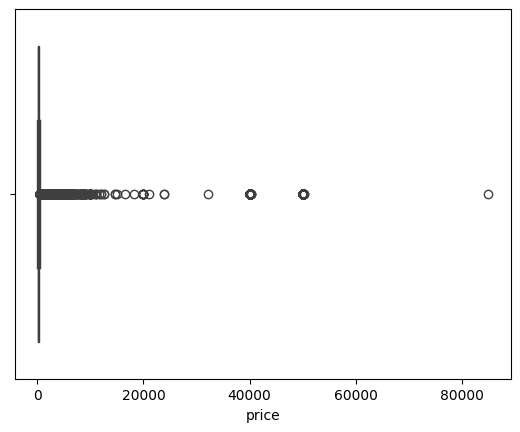

In [282]:
sns.boxplot(x='price', data= df1)

Wenn Sie sich nicht auf einen festen Wert ($1000) festlegen möchten, können Sie auch das 99. Perzentil Ihres eigenen Datensatzes verwenden. Das schließt die extremsten 1% der Ausreißer aus und zeigt 99% der Daten:

99. Perzentil liegt bei: $2999.73


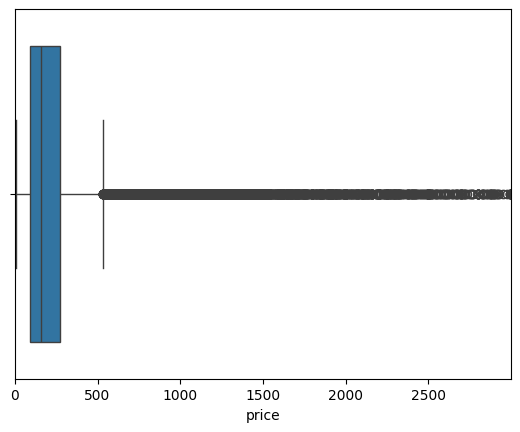

In [283]:
# Berechnung des 99. Perzentils
limit_99 = df1['price'].quantile(0.99)
print(f"99. Perzentil liegt bei: ${limit_99:.2f}") 

# Plot-Befehl mit dem berechneten Limit:
sns.boxplot(x='price', data=df1)
plt.xlim(0, limit_99) 
plt.show()

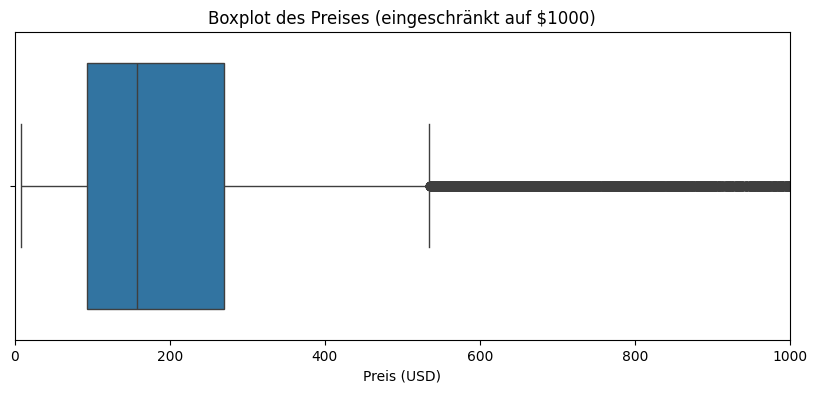

In [284]:
import seaborn as sns
import matplotlib.pyplot as plt

# Wir verwenden df_clean, den bereinigten Datensatz
# mit der numerischen 'price' Spalte

plt.figure(figsize=(10, 4))

# 1. Erstellen des Boxplots
sns.boxplot(x='price', data=df_clean)

# 2. EINSCHRÄNKUNG DER X-ACHSE (von 0 bis 1000 USD)
# Dies skaliert das Diagramm neu, um nur diesen Bereich anzuzeigen.
# Wenn Sie den Plot in der Zelle ausführen, wird er so angezeigt.
plt.xlim(0, 1000) 

plt.title('Boxplot des Preises (eingeschränkt auf $1000)')
plt.xlabel('Preis (USD)')
plt.show()

#### Scatterplots

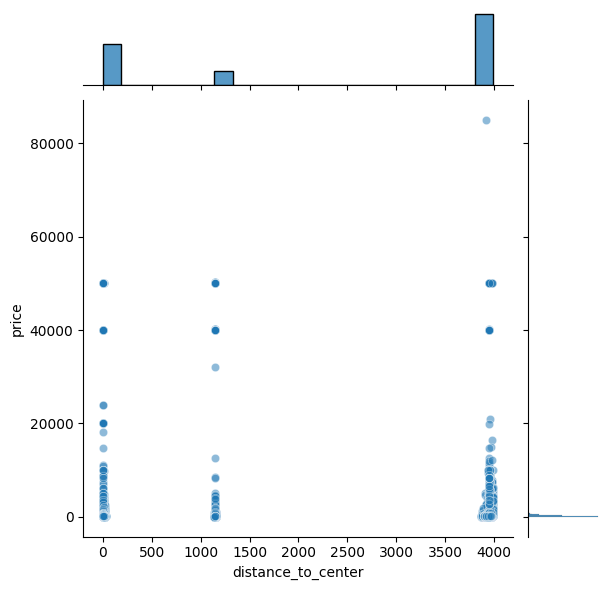

In [285]:
sns.jointplot(x='distance_to_center', y='price', data=df1, alpha=0.5)

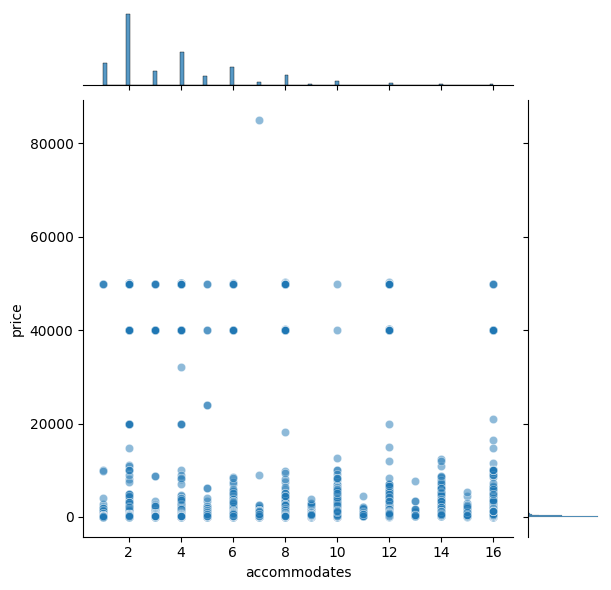

In [286]:
sns.jointplot(x='accommodates', y='price', data=df1, alpha=0.5)

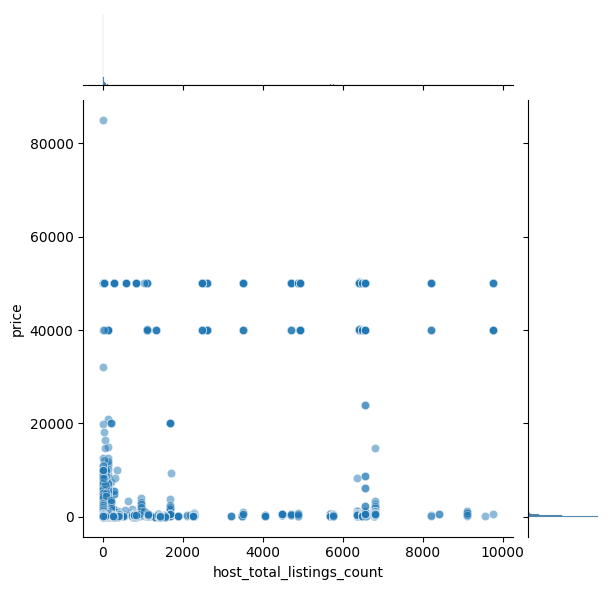

In [287]:
sns.jointplot(x='host_total_listings_count', y='price', data=df1, alpha=0.5)

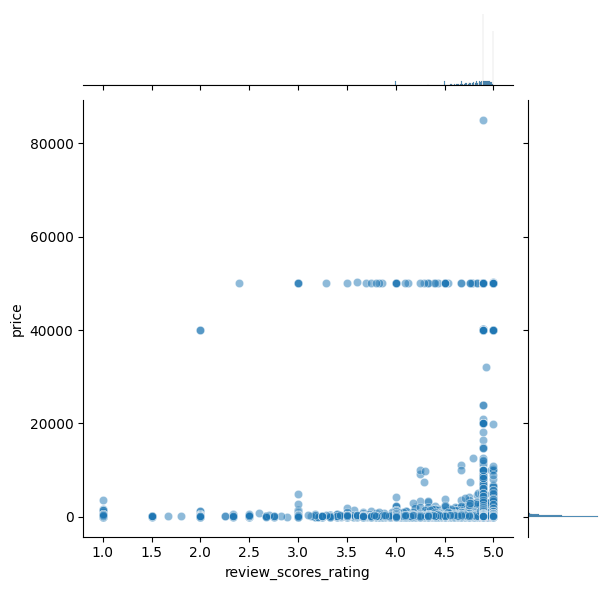

In [288]:

sns.jointplot(x='review_scores_rating', y='price', data=df1, alpha=0.5)

### Zielvariable Price - mit ln-transformation

Erstellen der neuen Spalte 'ln_price':

In [289]:
import numpy as np


df1['ln_price'] = np.log1p(df1['price'])

print("✅ Spalte 'ln_price' erfolgreich erstellt.")
print(df1[['price', 'ln_price']].head())

✅ Spalte 'ln_price' erfolgreich erstellt.
   price  ln_price
0  113.0  4.736198
1  100.0  4.615121
2  203.0  5.318120
3  288.0  5.666427
4  250.0  5.525453


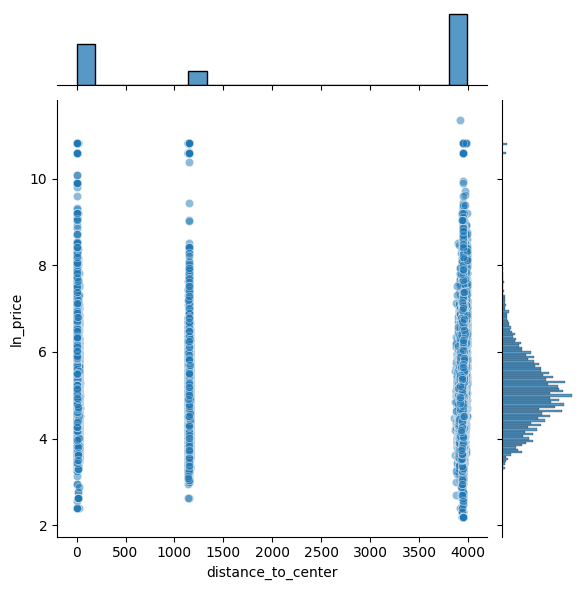

In [290]:
sns.jointplot(x='distance_to_center', y='ln_price', data=df1, alpha=0.5)

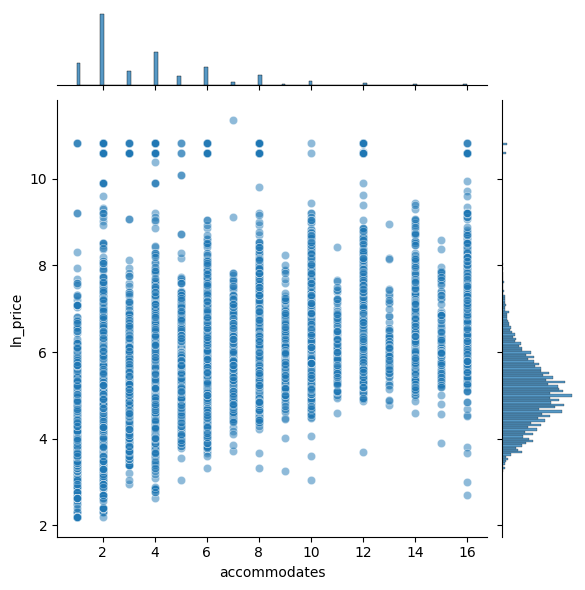

In [291]:
sns.jointplot(x='accommodates', y='ln_price', data=df1, alpha=0.5)

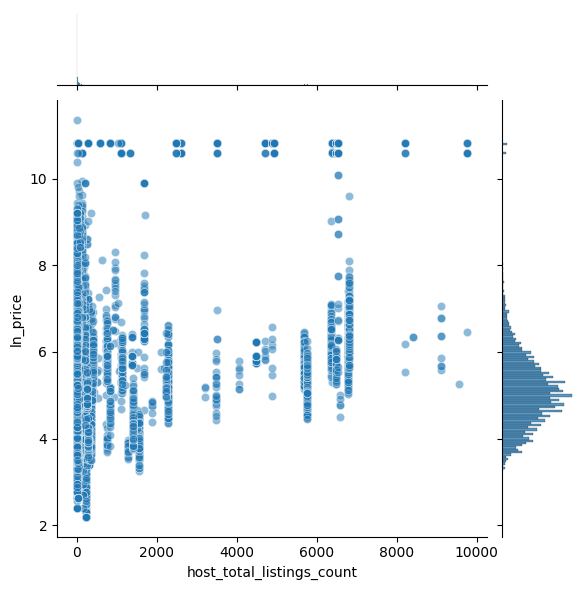

In [292]:
sns.jointplot(x='host_total_listings_count', y='ln_price', data=df1, alpha=0.5)

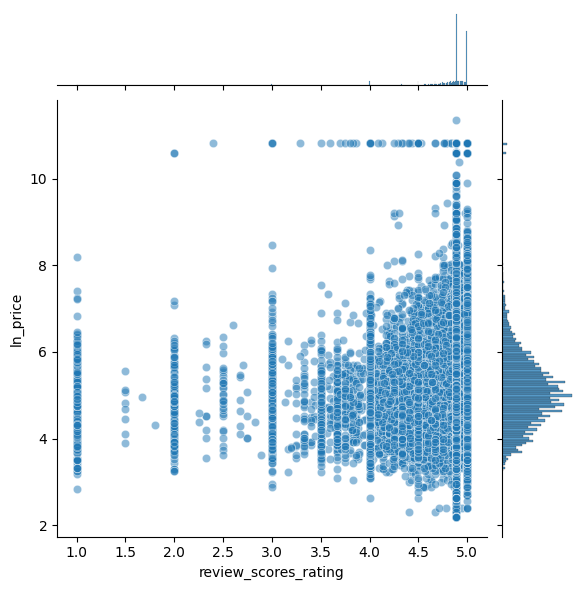

In [293]:
sns.jointplot(x='review_scores_rating', y='ln_price', data=df1, alpha=0.5)

### Gemeinsame Visualisierung von 'price' und 'ln_price'

KeyError: 'ln_price'

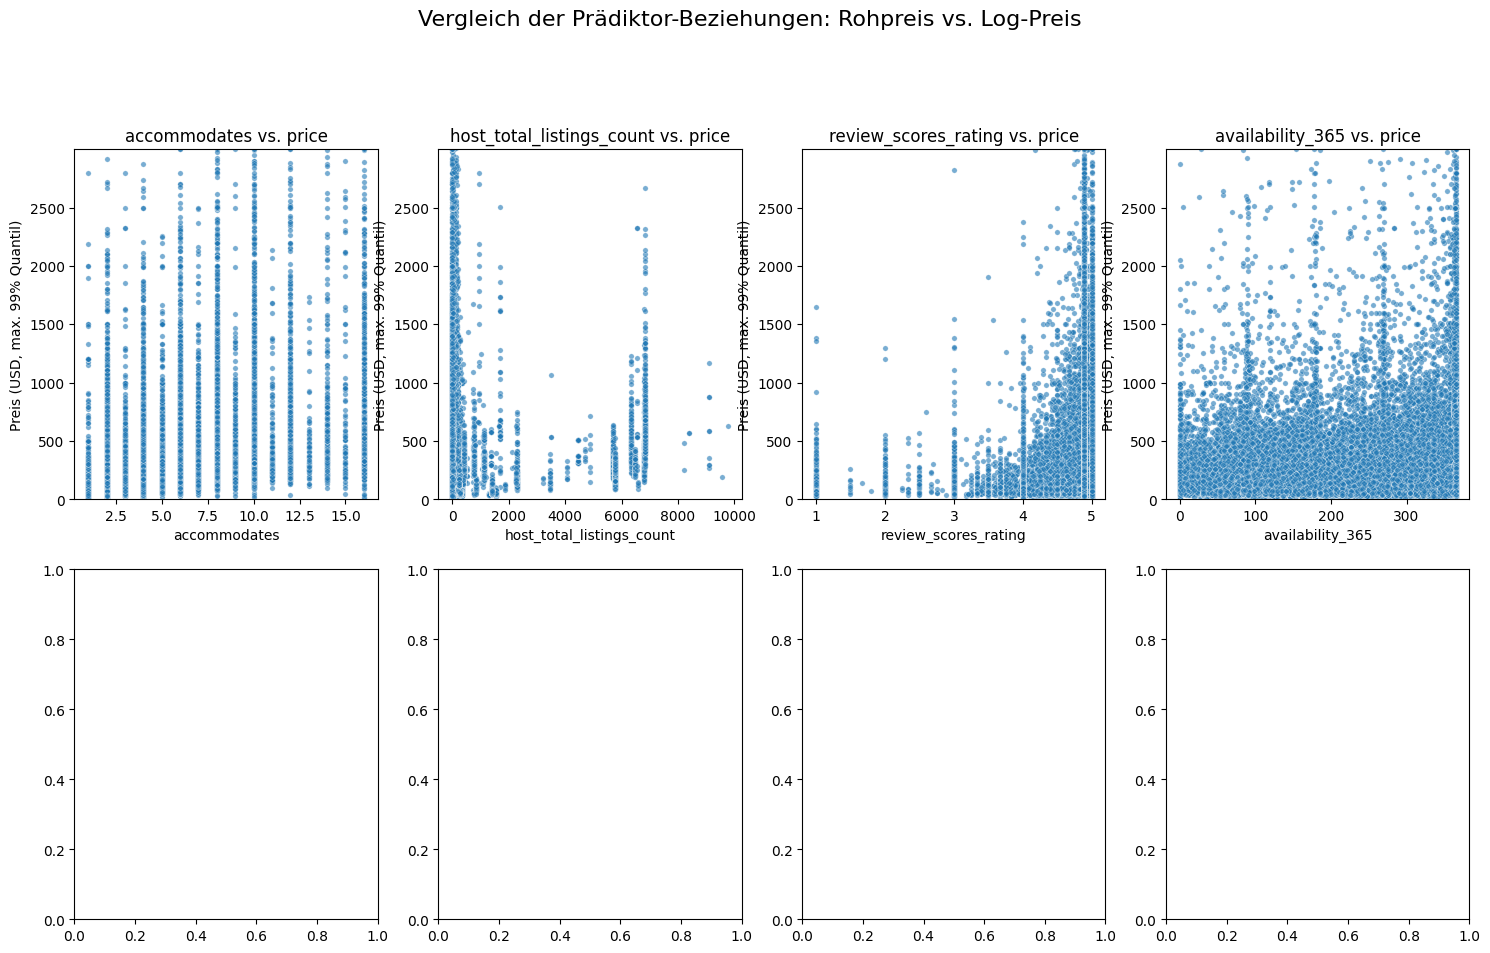

In [294]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Nur zur Sicherheit, falls nicht importiert

# Annahme: df_clean enthält die Spalten 'price' und 'ln_price'
PREDICTOR_SPALTEN = ['accommodates', 'host_total_listings_count', 'review_scores_rating', 'availability_365']
TARGET_SPALTEN = ['price', 'ln_price']

# Definition des maximalen Werts für die y-Achse des rohen Preises (zur besseren Sichtbarkeit)
PRICE_LIMIT = df_clean['price'].quantile(0.99)

# Erstellen der großen Figur: 2 Reihen, 3 Spalten (2x3 Grid)
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
plt.suptitle('Vergleich der Prädiktor-Beziehungen: Rohpreis vs. Log-Preis', fontsize=16, y=1.02)

# Abflachen des Achsen-Arrays, um es leicht durchlaufen zu können
# axes[0, 0], axes[0, 1], axes[0, 2] = Erste Reihe (price)
# axes[1, 0], axes[1, 1], axes[1, 2] = Zweite Reihe (ln_price)

# Äußere Schleife: Durchläuft die Zielvariablen (Reihen)
for row_index, target in enumerate(TARGET_SPALTEN):
    
    # Innere Schleife: Durchläuft die Prädiktoren (Spalten)
    for col_index, predictor in enumerate(PREDICTOR_SPALTEN):
        
        # Zugriff auf die korrekte Subplot-Position (axes[Reihe, Spalte])
        ax = axes[row_index, col_index]
        
        # Erstellen des Scatterplots
        sns.scatterplot(
            x=df_clean[predictor], 
            y=df_clean[target], 
            ax=ax, 
            alpha=0.6, 
            s=15 # Größe der Punkte
        )
        
        ax.set_title(f'{predictor} vs. {target}')
        ax.set_xlabel(predictor)
        
        # Nur für die obere Reihe (price): Y-Achse auf PRICE_LIMIT begrenzen
        if target == 'price':
            ax.set_ylim(0, PRICE_LIMIT)
            ax.set_ylabel('Preis (USD, max. 99% Quantil)')
        else:
            ax.set_ylabel('Log(1 + Preis)')
            
# Sicherstellen, dass die Plots sich nicht überlappen
plt.tight_layout()
plt.show()

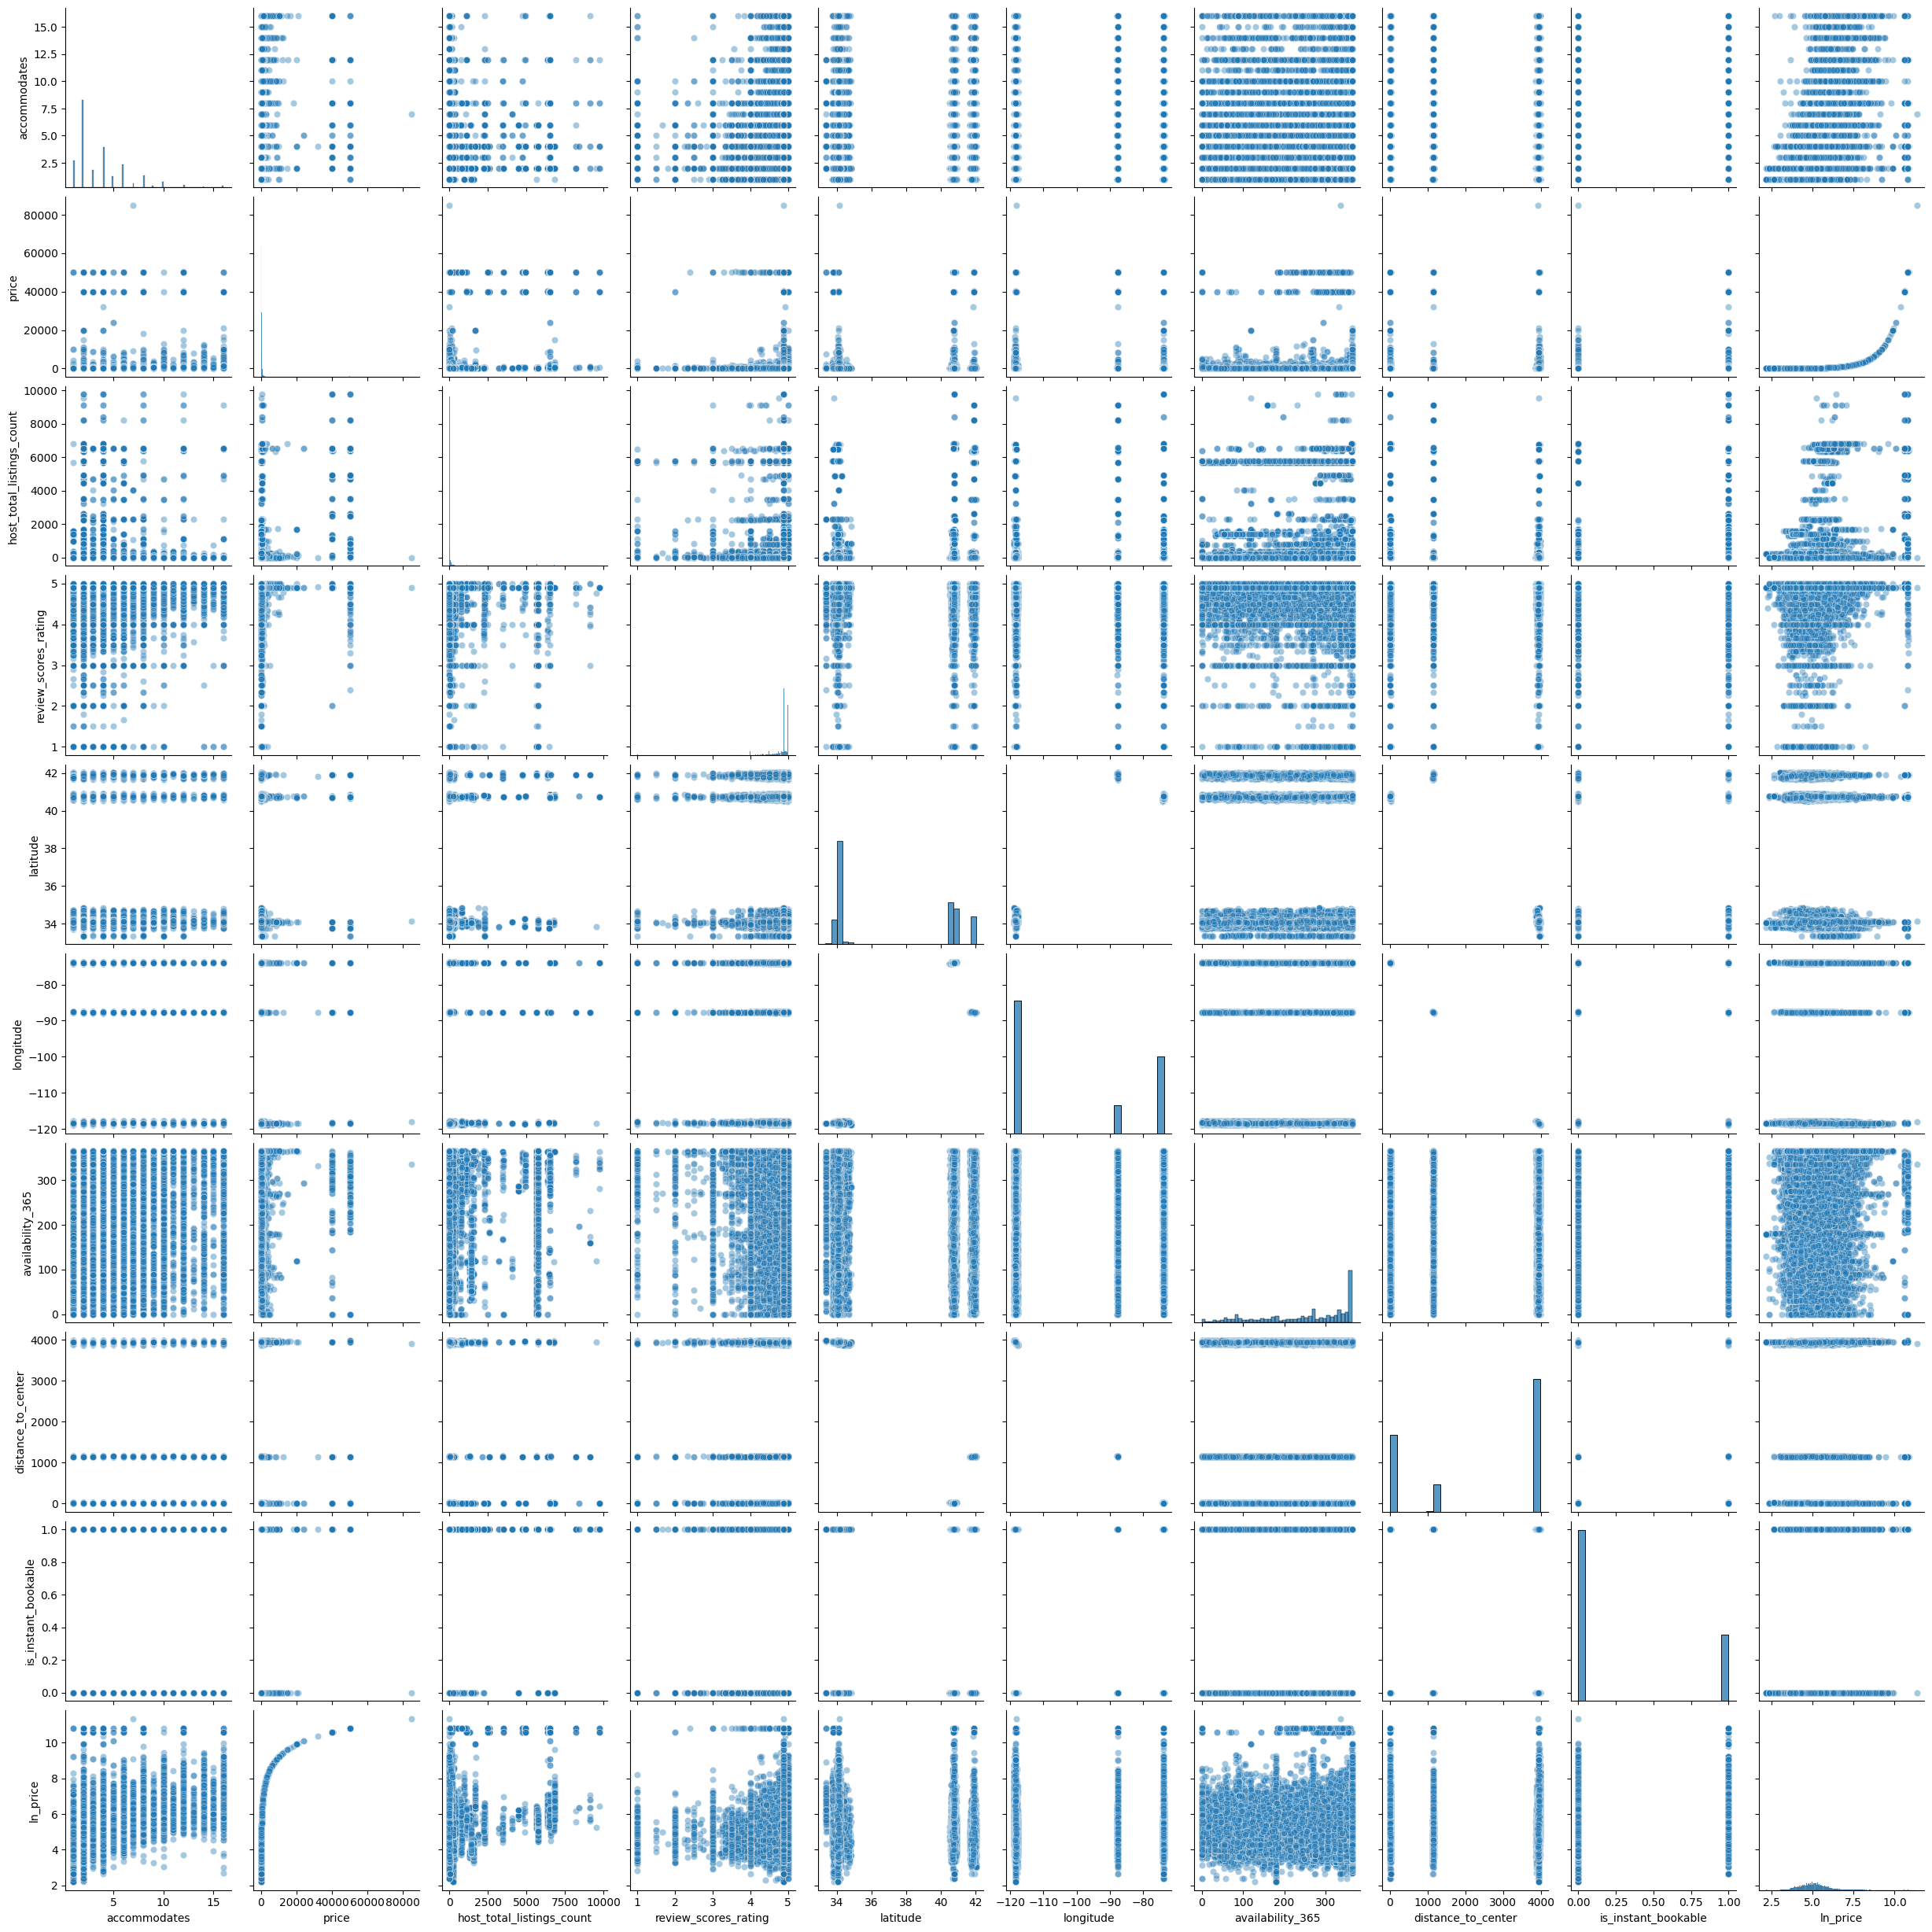

In [295]:
sns.pairplot(df1, kind='scatter', plot_kws={'alpha':0.4})

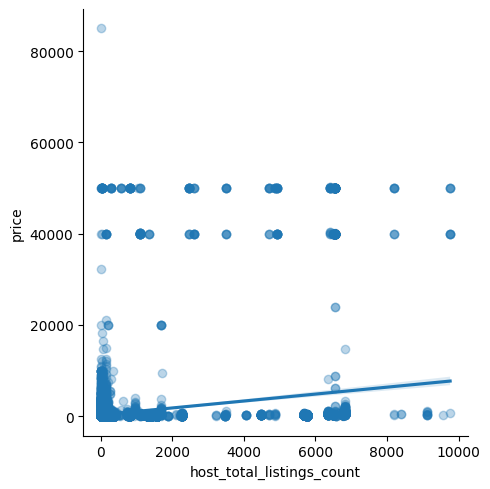

In [296]:
sns.lmplot(x = 'host_total_listings_count', 
           y = 'price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

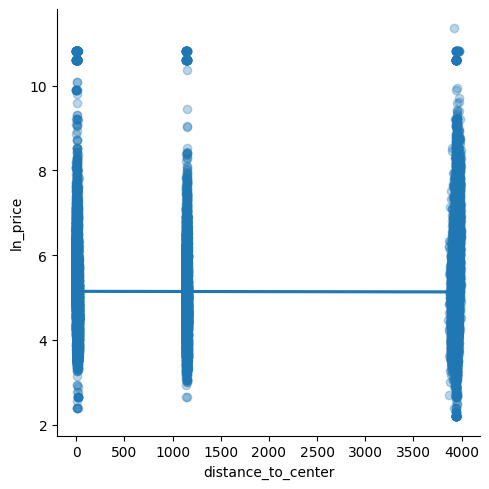

In [297]:
sns.lmplot(x = 'distance_to_center', 
           y = 'ln_price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

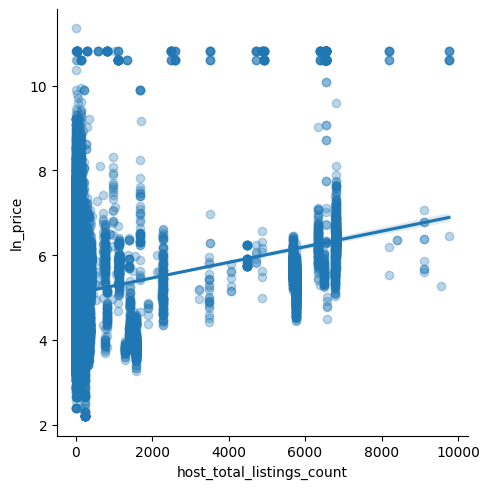

In [298]:
sns.lmplot(x = 'host_total_listings_count', 
           y = 'ln_price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

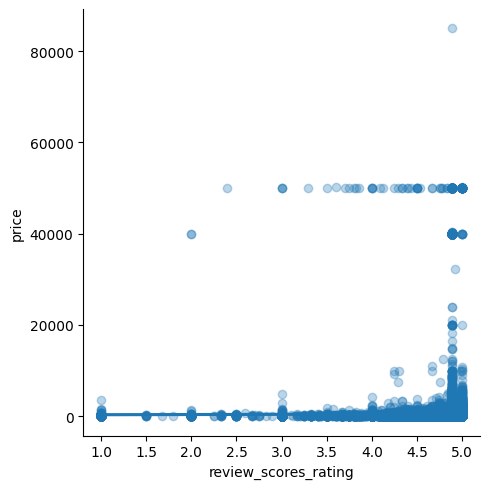

In [299]:
sns.lmplot(x = 'review_scores_rating', 
           y = 'price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

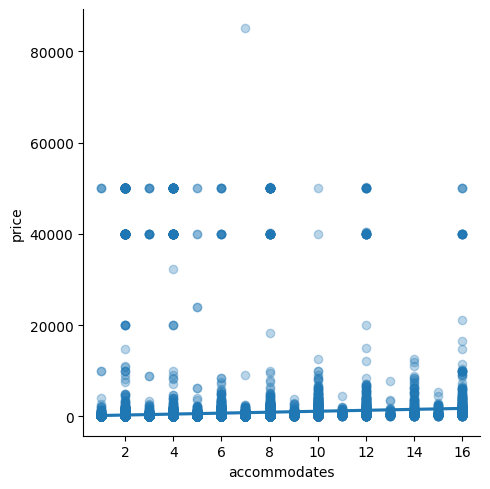

In [300]:
sns.lmplot(x = 'accommodates', 
           y = 'price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

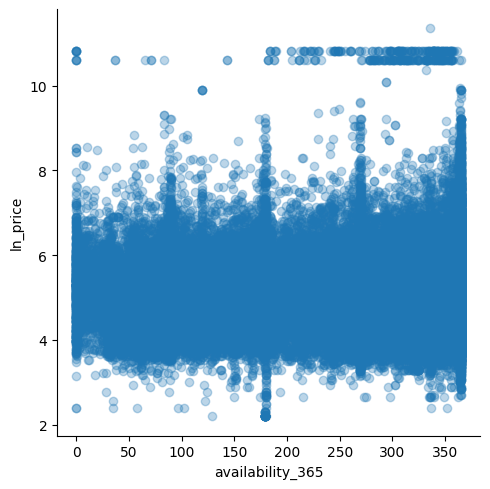

In [301]:
sns.lmplot(x = 'availability_365', 
           y = 'ln_price',
           data = df1, 
           scatter_kws={'alpha':0.3}) 

In [302]:
from sklearn.model_selection import train_test_split

In [303]:
X = df1[['distance_to_center', 'host_total_listings_count', 'accommodates', 'availability_365', 'is_instant_bookable']]
y = df1['ln_price']

In [304]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [305]:
y_train

20097    4.204693
83934    5.278115
84215    4.744932
46033    5.402677
3264     4.990433
           ...   
46774    4.007333
7062     4.762174
77401    3.951244
963      4.356709
21950    6.165418
Name: ln_price, Length: 46079, dtype: float64

# Training the model

In [306]:
from sklearn.linear_model import LinearRegression

In [307]:
lm = LinearRegression()

In [308]:
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Koeffizienten

In [309]:
lm.coef_

array([-5.28152210e-05,  2.08893816e-04,  1.96200401e-01, -3.52056548e-05,
        1.86493961e-01])

In [310]:
cdf = pd.DataFrame(lm.coef_, X.columns, columns=['Coef'])
print(cdf)

                               Coef
distance_to_center        -0.000053
host_total_listings_count  0.000209
accommodates               0.196200
availability_365          -0.000035
is_instant_bookable        0.186494


### Predictions

In [311]:
predictions = lm.predict(X_test)

In [312]:
predictions

array([4.61361365, 5.17583037, 4.65987938, ..., 7.3419937 , 4.80005794,
       4.60068276], shape=(19749,))

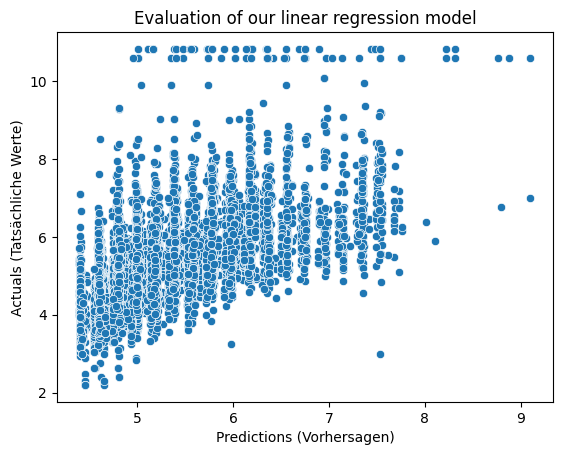

In [313]:
sns.scatterplot(x=predictions, y=y_test)
plt.xlabel("Predictions (Vorhersagen)")
plt.ylabel("Actuals (Tatsächliche Werte)")
plt.title("Evaluation of our linear regression model")
plt.show()

In [314]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [315]:
print("Mean Absolute Error: ", mean_absolute_error(y_test, predictions))
print("Mean Squared Error: ", mean_squared_error(y_test, predictions))
print("RMSE: ", math.sqrt(mean_squared_error(y_test, predictions)))

Mean Absolute Error:  0.5199753178513881
Mean Squared Error:  0.516300220208543
RMSE:  0.7185403400008541


## Ent-Transformation (wichtiger Schritt)

Um die Modellgüte korrekt zu interpretieren, müssen die Fehlerwerte aus dem logarithmierten Raum zurück in die ursprüngliche Einheit **USD** transformiert werden.

Da im Modell die natürliche Logarithmusfunktion verwendet wurde,

$$
\[
y_{\text{log}} = \ln(y),
\]
$$
erfolgt die Rücktransformation mit der **Exponentialfunktion**:
$$
\[
y = e^{y_{\text{log}}}
\]
$$
---

## Schätzung des mittleren absoluten Fehlers (MAE in USD)

Der mittlere absolute Fehler im Log-Raum (\(\text{MAE}_{\text{log}}\)) lässt sich näherungsweise in den ursprünglichen Raum transformieren durch:

$$
\[
\text{MAE}_{\text{USD}} \approx e^{\text{MAE}_{\text{log}}} - 1
\]
$$

Setzt man den geschätzten Wert ein:

$$
\[
\text{MAE}_{\text{USD}} \approx e^{0.59} - 1
\]
$$

$$
\[
\text{MAE}_{\text{USD}} \approx 1.80 - 1 = 0.80
\]
$$
---

## Interpretation

Das bedeutet, dass das Modell im Durchschnitt einen **relativen Fehler von etwa 80 %** aufweist.

### Beispiel

Angenommen, der wahre Preis beträgt:

\[
y = 100 \ \text{USD}
\]

Dann liegt die Modellvorhersage im Mittel in folgendem Bereich:

\[
100 \cdot (1 - 0.80) \le \hat{y} \le 100 \cdot (1 + 0.80)
\]

\[
20 \ \text{USD} \le \hat{y} \le 180 \ \text{USD}
\]

⚠️ Diese Interpretation ist **vereinfachend**, aber notwendig, um die praktische Modellgüte im ursprünglichen Maßstab zu beurteilen.


<Axes: ylabel='ln_price'>

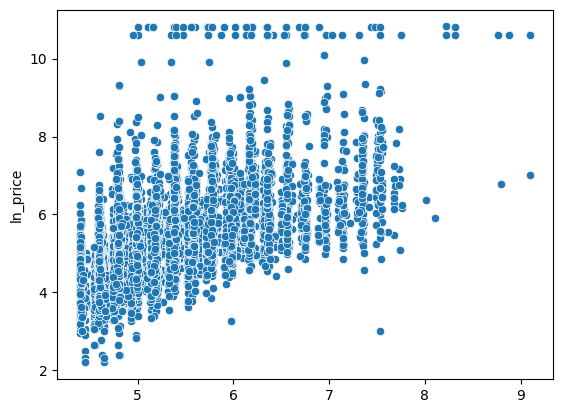

In [316]:
sns.scatterplot(x=predictions, y=y_test)

### Residuals

In [317]:
residuals = y_test - predictions
residuals

63075    0.436242
37767    0.017126
53347   -1.104531
46433    0.195391
64056    0.026800
           ...   
39911    0.432562
6335    -0.482039
21306   -0.076564
84558    0.478057
47984    0.195108
Name: ln_price, Length: 19749, dtype: float64

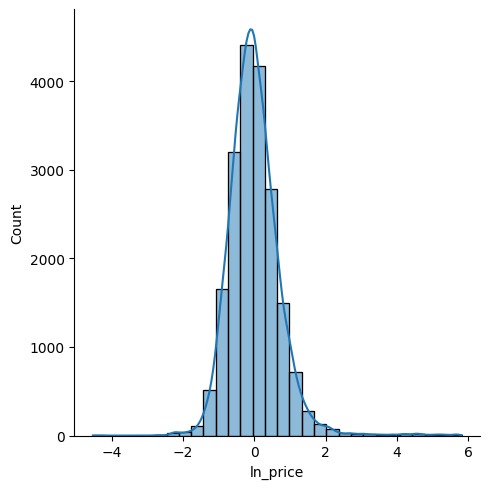

In [318]:
sns.displot(residuals, bins=30, kde=True)

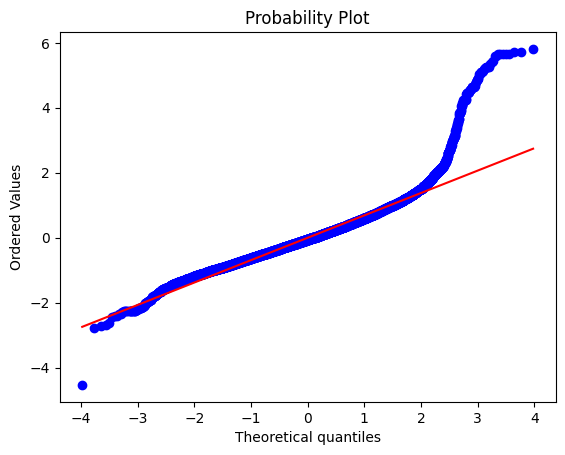

In [319]:
import pylab
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=pylab)
pylab.show()

In [ ]:
import numpy as np
from sklearn.metrics import r2_score

# 1. Berechne den R²
y_pred = lm.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R²-Wert: {r2:.4f}")

# 2. Berechne den Adjusted R²
n = X_test.shape[0]  # Stichprobengröße (Anzahl der Testdatenpunkte)
k = X_test.shape[1]  # Anzahl der Features (Spalten)

# Adjusted R² Formel: 1 - (1 - R²) * (n - 1) / (n - k - 1)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
print(f"Adjusted R²-Wert: {adj_r2:.4f}")

R²-Wert: 0.3928
Adjusted R²-Wert: 0.3927
